# Importing Libraries

In [142]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.inspection import permutation_importance
import warnings
warnings.filterwarnings("ignore")
plt.style.use('seaborn-v0_8')

# 1. Load and Clean Data

In [143]:
df = pd.read_excel('DO_5DayAverage.xlsx')

for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = df[col].astype(str).str.replace(r'[/,]', '.', regex=True)
        df[col] = pd.to_numeric(df[col], errors='coerce')

target = '      DO'
df = df.dropna(subset=[target])

X = df.drop(columns=[target])
y = df[target]

print(f"Final dataset size: {len(df)} samples")

Final dataset size: 2480 samples


# 2. Correlation Matrix and Pair Plot

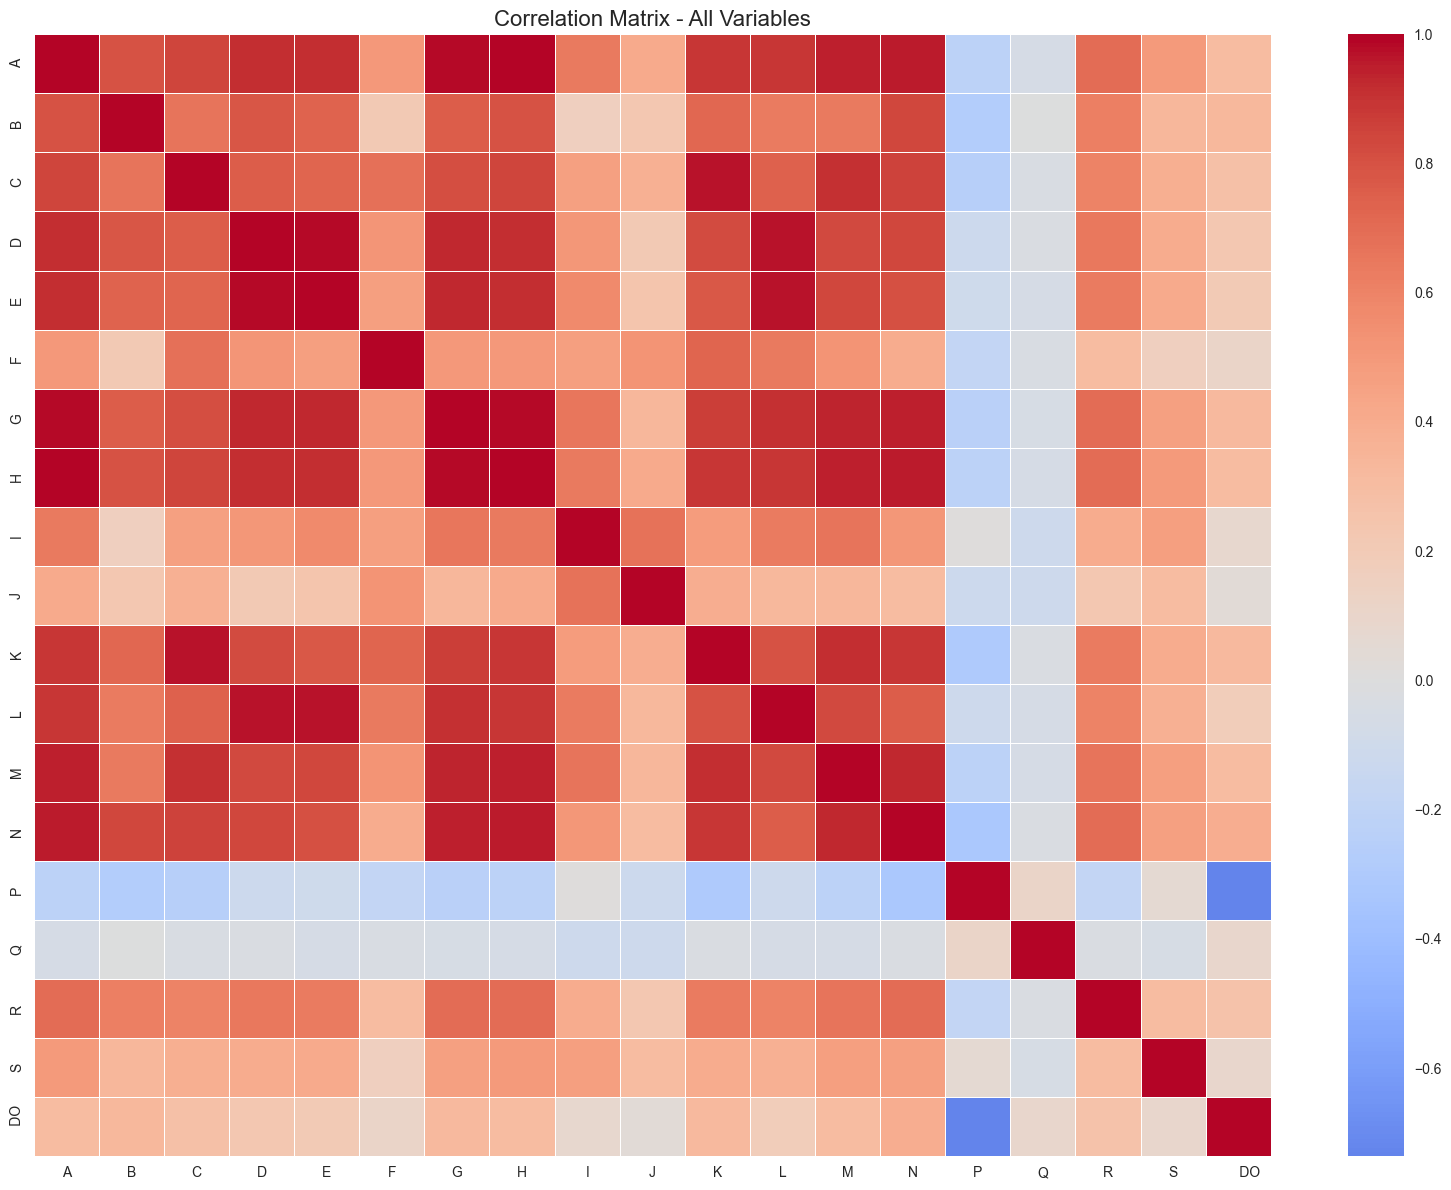

In [144]:
plt.figure(figsize=(16, 12))
corr = df.corr()
sns.heatmap(corr, cmap='coolwarm', center=0, linewidths=0.5, annot=False)
plt.title("Correlation Matrix - All Variables", fontsize=16)
plt.tight_layout()
plt.show()

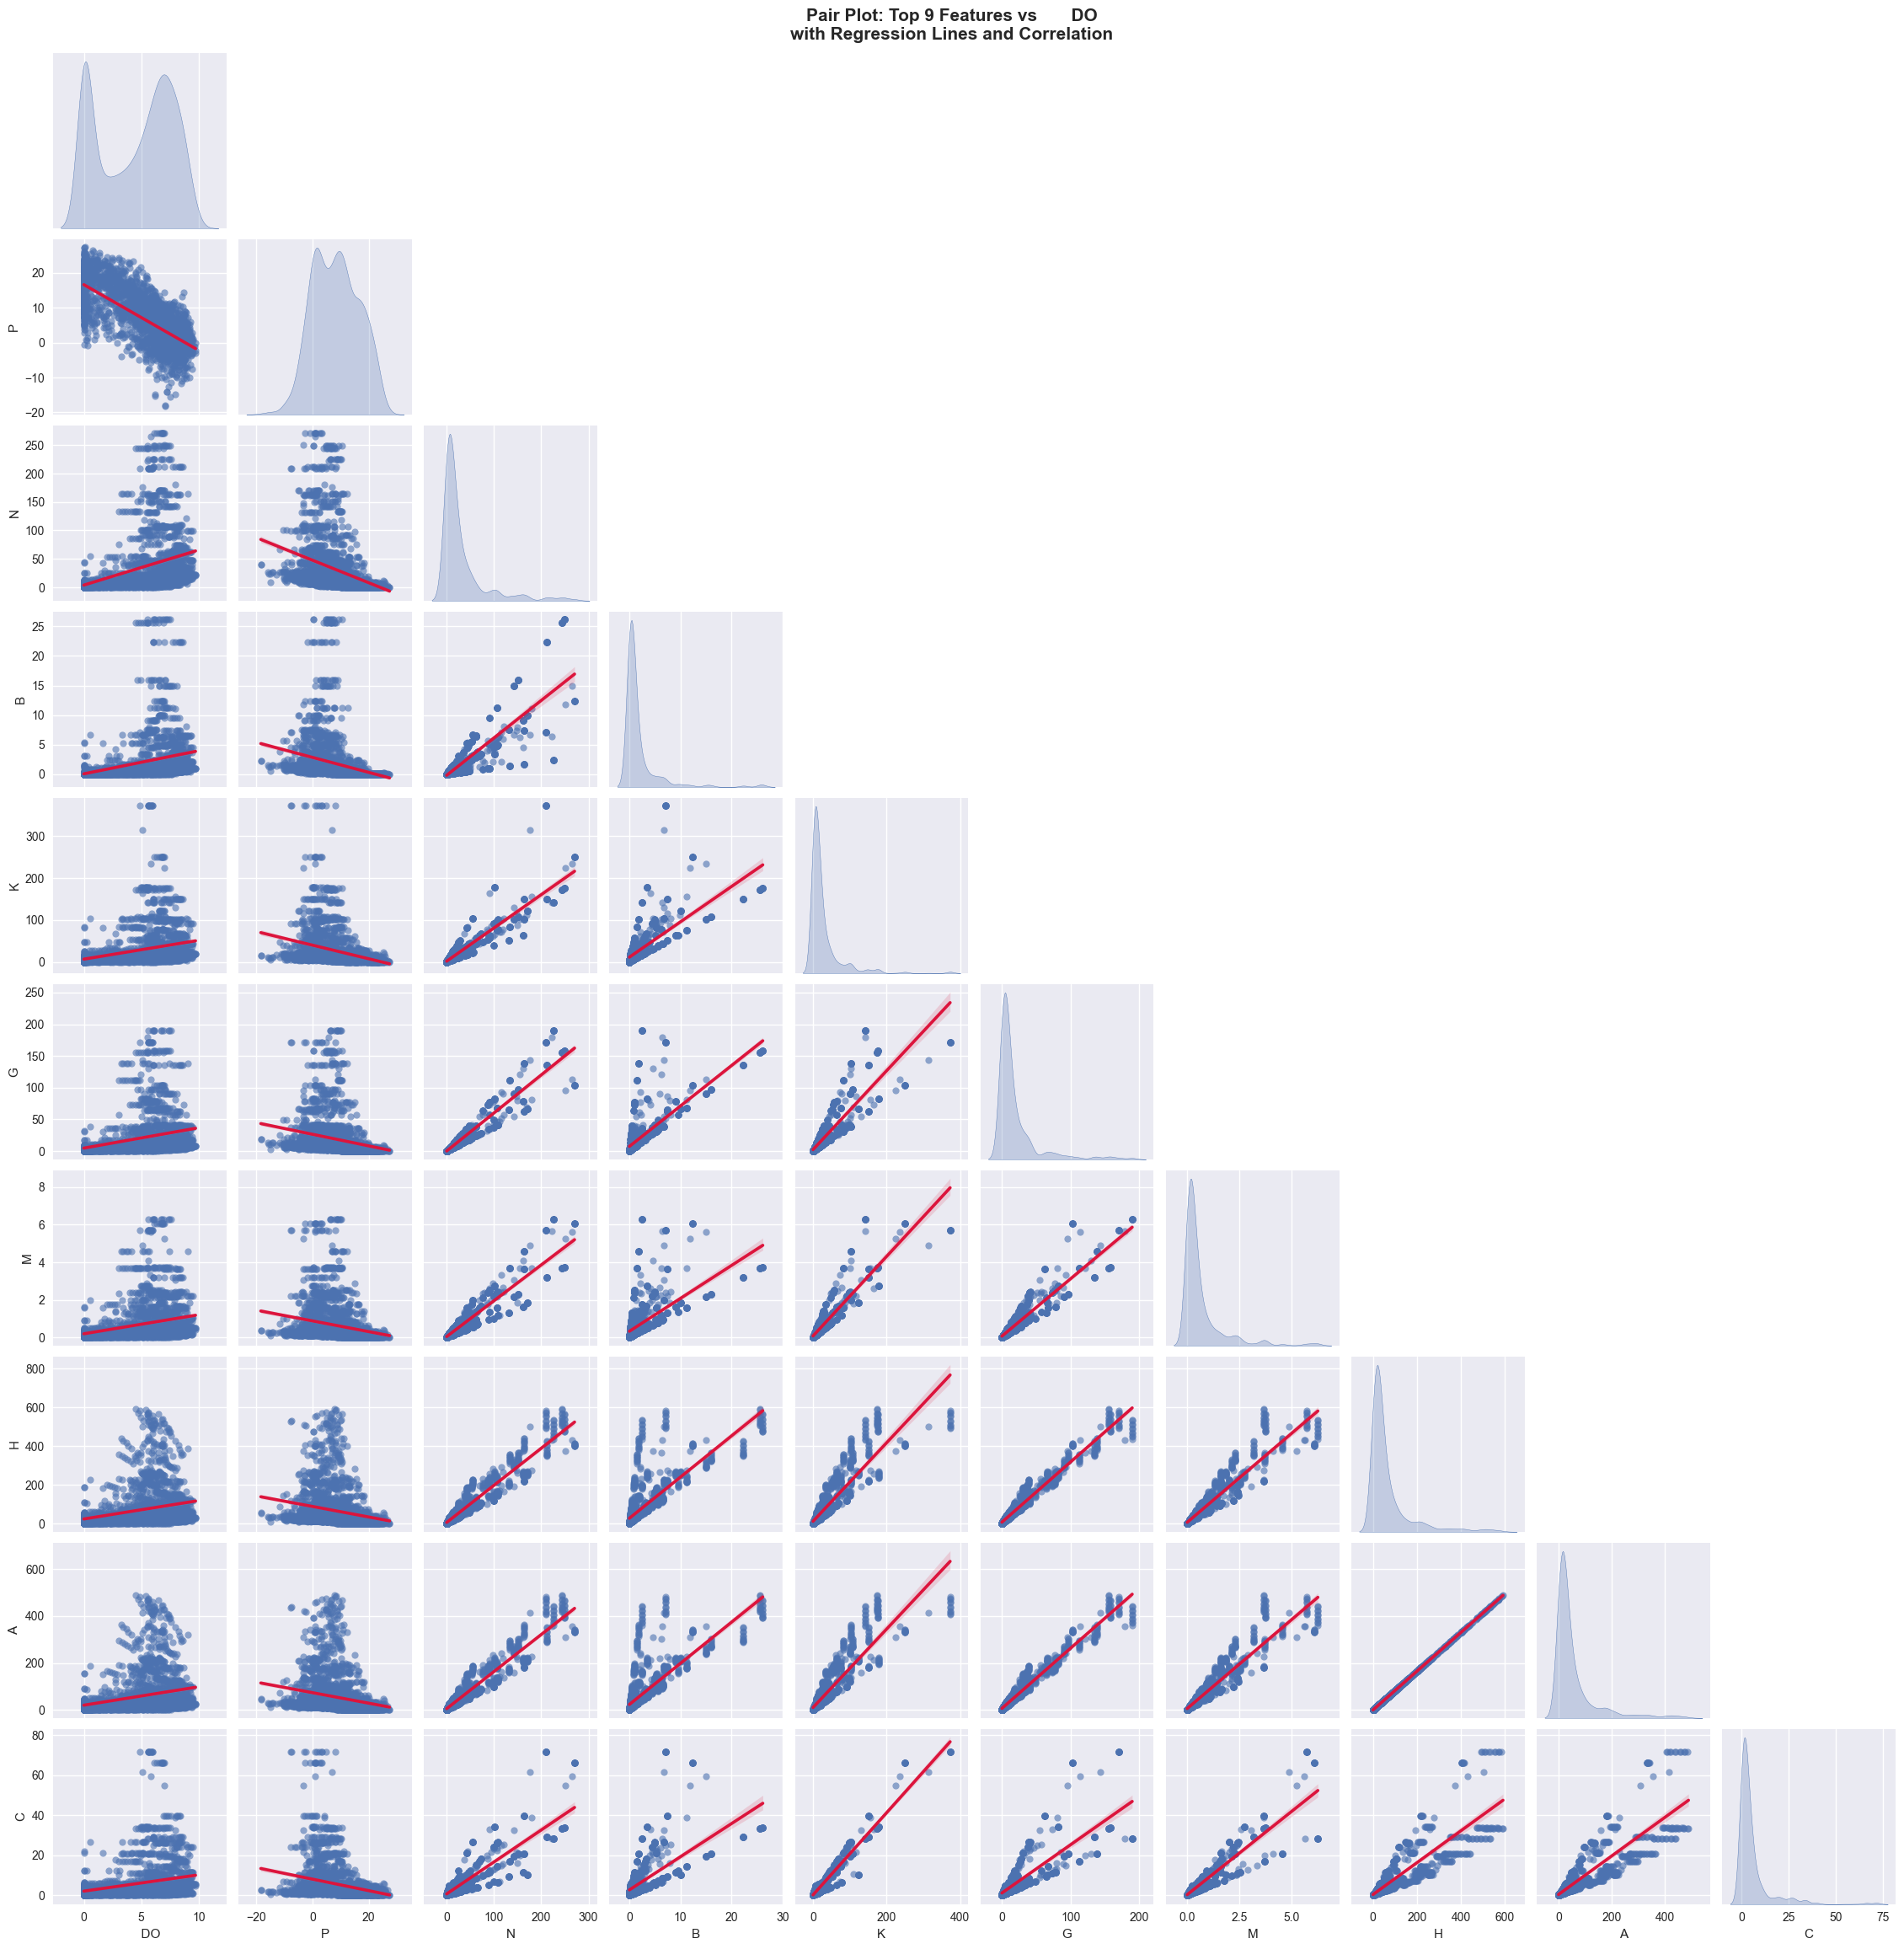

In [145]:
important_features = df.corr()[target].abs().sort_values(ascending=False).head(10).index.tolist()
data_for_plot = df[important_features].dropna()

def corrfunc(x, y, **kw):
    r, p = linregress(x, y)[0:2]
    ax = plt.gca()
    color = 'darkred' if abs(r) > 0.7 else 'orange' if abs(r) > 0.5 else 'gray'
    size = 13 if abs(r) > 0.7 else 11
    p_text = "p < 0.001" if p < 0.001 else f"p = {p:.3f}"
    ax.annotate(f"r = {r:.3f}\n{p_text}", xy=(0.5, 0.82), xycoords='axes fraction',
                ha='center', fontsize=size, color=color,
                bbox=dict(boxstyle="round,pad=0.4", facecolor="white", alpha=0.9, edgecolor=color))

g = sns.pairplot(data_for_plot, diag_kind='kde', kind='reg', corner=True, height=2.3,
                 plot_kws={'line_kws':{'color':'crimson'}, 'scatter_kws':{'alpha':0.6, 's':35}})
g.map_upper(corrfunc)
g.fig.suptitle(f"Pair Plot: Top 9 Features vs {target}\nwith Regression Lines and Correlation",
               fontsize=15, y=1.01, weight='bold')
plt.show()

## Correlation with target (DO)

In [146]:
do_corr = corr[target].drop(target).sort_values(ascending=False, key=abs)

print("\n" + "="*60)
print("Top 15 Features Most Correlated with DO (absolute value):")
print("="*60)
print(do_corr.head(15).round(3))


Top 15 Features Most Correlated with DO (absolute value):
P   -0.737
N    0.392
B    0.329
K    0.323
G    0.323
M    0.313
H    0.302
A    0.302
C    0.277
R    0.263
D    0.230
E    0.209
L    0.184
F    0.116
S    0.088
Name:       DO, dtype: float64


## Horizontal bar plot of top 20 correlations

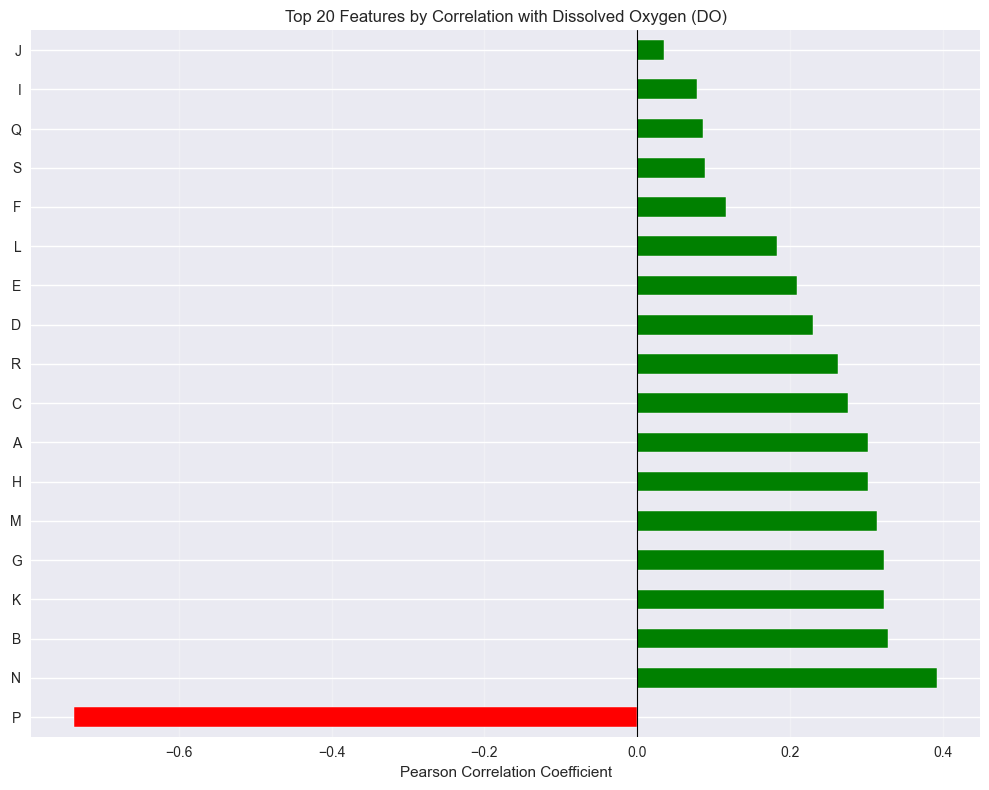

In [147]:
plt.figure(figsize=(10, 8))
top20 = do_corr.head(20)
colors = ['red' if x < 0 else 'green' for x in top20]
top20.plot.barh(color=colors)
plt.title("Top 20 Features by Correlation with Dissolved Oxygen (DO)")
plt.xlabel("Pearson Correlation Coefficient")
plt.axvline(0, color='black', linewidth=0.8)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

# 3. Train-Test Split

In [148]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Models + GridSearchCV

In [149]:
models = {
    "XGBoost": (
        xgb.XGBRegressor(random_state=42, n_estimators=800, tree_method='hist'),
        {
            "learning_rate": [0.05, 0.1],
            "max_depth": [6, 10],
            "subsample": [0.8, 1.0],
            "reg_lambda": [1, 10]
        }
    ),
    "HistGradientBoosting": (
        HistGradientBoostingRegressor(random_state=42, max_iter=800),
        {
            "learning_rate": [0.05, 0.1],
            "max_depth": [None, 15],
            "max_leaf_nodes": [31, 127]
        }
    ),
    "RandomForest": (
        RandomForestRegressor(random_state=42, n_estimators=800),
        {
            "max_depth": [None, 20],
            "min_samples_leaf": [1, 2],
            "max_features": ['sqrt', None]
        }
    )
}

results = []
best_model = None
best_mae = float('inf')
best_name = ""

print("\nTraining models with GridSearchCV...")
for name, (model, params) in models.items():
    print(f"→ Training {name}...")
    grid = GridSearchCV(
        estimator=model,
        param_grid=params,
        scoring='neg_mean_absolute_error',
        cv=5,
        n_jobs=-1,
        verbose=0
    )
    grid.fit(X_train, y_train)

    pred = grid.predict(X_test)
    mae = mean_absolute_error(y_test, pred)
    r2 = r2_score(y_test, pred)

    if mae < best_mae:
        best_mae = mae
        best_model = grid.best_estimator_
        best_name = name

    results.append({"Model": name, "MAE": mae, "R²": r2, "Best_Params": grid.best_params_})
    print(f"   {name} → MAE: {mae:.4f} | R²: {r2:.4f}")


Training models with GridSearchCV...
→ Training XGBoost...
   XGBoost → MAE: 0.3710 | R²: 0.9648
→ Training HistGradientBoosting...
   HistGradientBoosting → MAE: 0.3713 | R²: 0.9693
→ Training RandomForest...
   RandomForest → MAE: 0.4252 | R²: 0.9535


# 5. Final Results Table

In [150]:
results_df = pd.DataFrame(results).sort_values("MAE")
print("\n" + "="*80)
print("FINAL RESULTS (sorted by MAE):")
print("="*80)
print(results_df.round(5))
print(f"\nBest Model: {best_name} with MAE = {best_mae:.4f} mg/L")


FINAL RESULTS (sorted by MAE):
                  Model      MAE       R²  \
0               XGBoost  0.37104  0.96477   
1  HistGradientBoosting  0.37127  0.96930   
2          RandomForest  0.42516  0.95348   

                                         Best_Params  
0  {'learning_rate': 0.05, 'max_depth': 6, 'reg_l...  
1  {'learning_rate': 0.05, 'max_depth': None, 'ma...  
2  {'max_depth': 20, 'max_features': 'sqrt', 'min...  

Best Model: XGBoost with MAE = 0.3710 mg/L


# 6. Method 1: Built-in Feature Importance (Gain)


Top 15 Features by Built-in Importance (XGBoost - Gain):
   Feature  Importance
13       N    0.383107
1        B    0.282367
9        J    0.122431
8        I    0.047416
5        F    0.034633
16       R    0.026669
14       P    0.015932
4        E    0.015895
2        C    0.015690
6        G    0.011800
11       L    0.009982
17       S    0.009149
3        D    0.008421
10       K    0.005674
12       M    0.004094


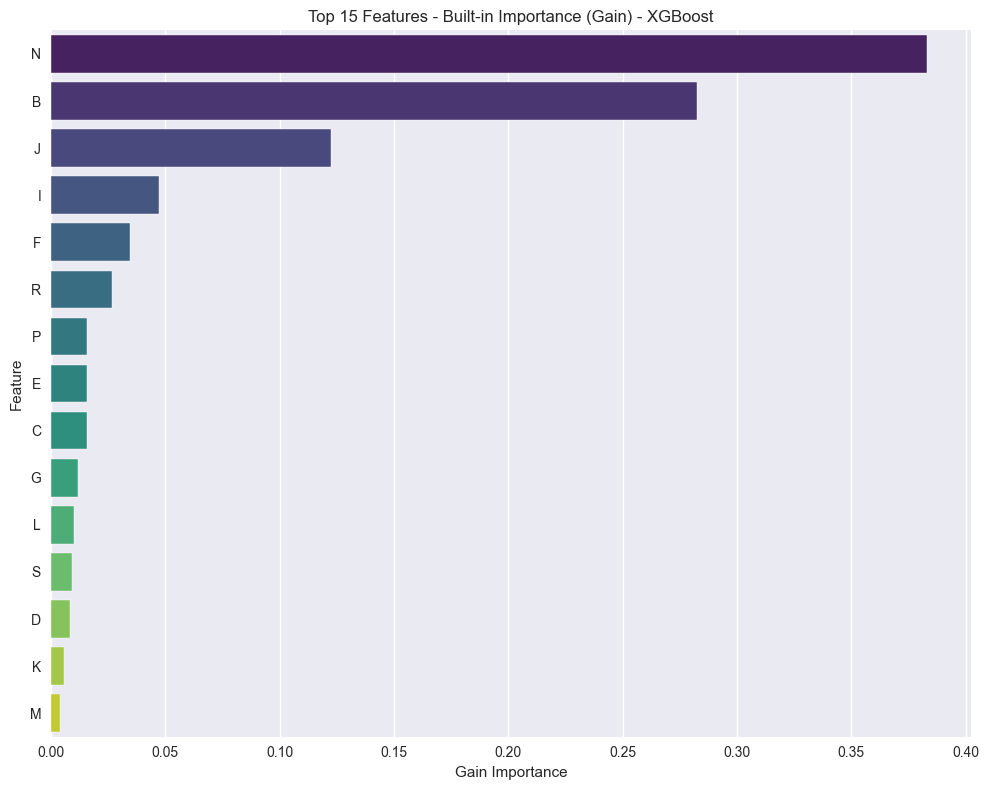

In [151]:
print(f"\nTop 15 Features by Built-in Importance ({best_name} - Gain):")

importances = best_model.feature_importances_

gain_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importances
}).sort_values("Importance", ascending=False)

print(gain_df.head(15))

plt.figure(figsize=(10, 8))
top15_gain = gain_df.head(15)
sns.barplot(data=top15_gain, x="Importance", y="Feature", palette="viridis")
plt.title(f"Top 15 Features - Built-in Importance (Gain) - {best_name}")
plt.xlabel("Gain Importance")
plt.tight_layout()
plt.show()

# 7. Method 2: Permutation Importance


Computing Permutation Importance
Top 15 Features by Permutation Importance:
   Feature  Importance
1        B    0.410637
13       N    0.189877
16       R    0.149245
9        J    0.144037
0        A    0.130049
14       P    0.108003
17       S    0.067010
5        F    0.036053
6        G    0.033037
8        I    0.032606
2        C    0.021251
4        E    0.006784
15       Q    0.005026
12       M    0.002990
3        D    0.002749


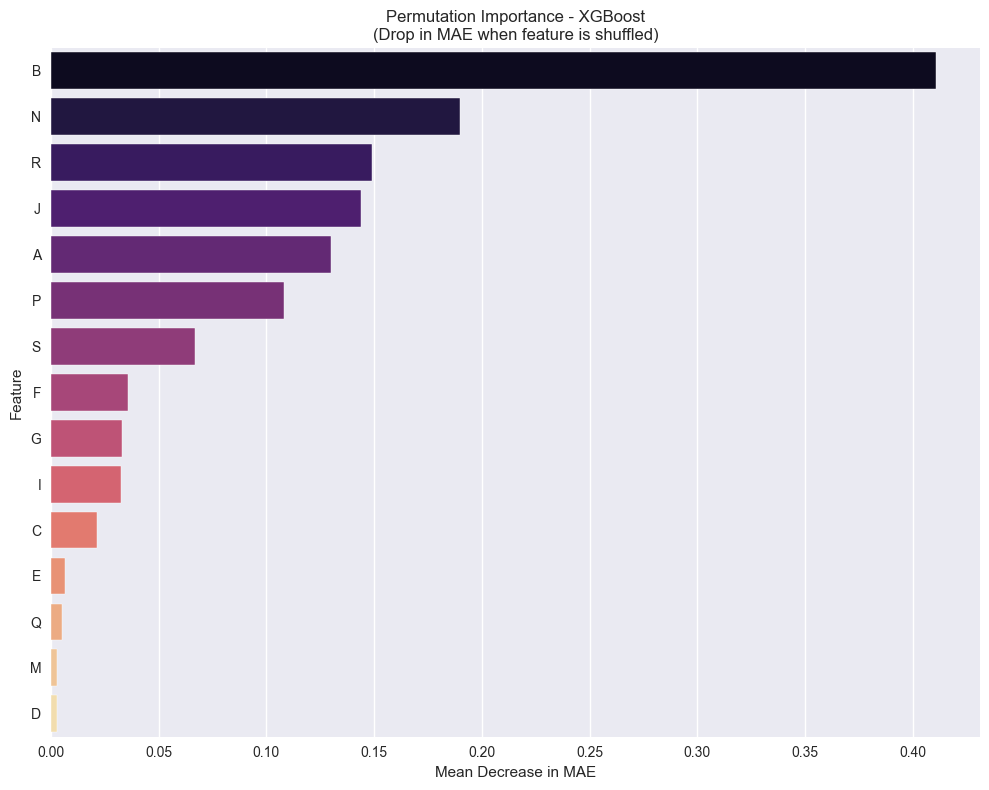

In [155]:
print(f"\nComputing Permutation Importance")
perm_importance = permutation_importance(
    best_model, X_test, y_test,
    n_repeats=10, random_state=42, n_jobs=-1
)

perm_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": perm_importance.importances_mean
}).sort_values("Importance", ascending=False)

print("Top 15 Features by Permutation Importance:")
print(perm_df.head(15))

plt.figure(figsize=(10, 8))
top15_perm = perm_df.head(15)
sns.barplot(data=top15_perm, x="Importance", y="Feature", palette="magma")
plt.title(f"Permutation Importance - {best_name}\n(Drop in MAE when feature is shuffled)")
plt.xlabel("Mean Decrease in MAE")
plt.tight_layout()
plt.show()

# 8. Comparison of Both Methods

In [156]:
print("\nComparison: Gain vs Permutation Importance (Top 10)")
compare = gain_df.head(10)[["Feature", "Importance"]].rename(columns={"Importance": "Gain"})
compare = compare.merge(
    perm_df.head(10)[["Feature", "Importance"]].rename(columns={"Importance": "Permutation"}),
    on="Feature", how="outer"
).fillna(0)
print(compare.round(5))


Comparison: Gain vs Permutation Importance (Top 10)
   Feature     Gain  Permutation
0        A  0.00000      0.13005
1        B  0.28237      0.41064
2        C  0.01569      0.00000
3        E  0.01589      0.00000
4        F  0.03463      0.03605
5        G  0.01180      0.03304
6        I  0.04742      0.03261
7        J  0.12243      0.14404
8        N  0.38311      0.18988
9        P  0.01593      0.10800
10       R  0.02667      0.14924
11       S  0.00000      0.06701


# 9. Sample Predictions

In [157]:
print(f"\nSample Predictions using {best_name}:")
sample = X_test.iloc[:5].copy()
sample["DO_Actual"] = y_test.iloc[:5].values.round(3)
sample["DO_Predicted"] = best_model.predict(X_test.iloc[:5]).round(3)
sample["Absolute_Error"] = (sample["DO_Actual"] - sample["DO_Predicted"]).abs().round(3)

print(sample[["DO_Actual", "DO_Predicted", "Absolute_Error"]])


Sample Predictions using XGBoost:
      DO_Actual  DO_Predicted  Absolute_Error
767       7.764         7.794           0.030
259       4.727         5.054           0.327
1068      6.061         6.534           0.473
1769      5.718         5.468           0.250
56        4.583         4.425           0.158
